In [100]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, TimeDistributed, LSTM
import time
from datetime import datetime
from tensorflow import keras
import random
import numpy as np
import cv2
import os


In [101]:
# import os
# import cv2

# TRAIN_DIR = r"C:\Users\Shubham\Downloads\Detection-of-Violent-Scenes-in-Cartoon-Movies-main (1)\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train"

# def video_to_clip_frames(video_path, out_dir, max_frames=24):
#     os.makedirs(out_dir, exist_ok=True)
#     cap = cv2.VideoCapture(video_path)

#     if not cap.isOpened():
#         print("Cannot open:", video_path)
#         return 0
# 
#     i = 0
#     while True:
#         ret, frame = cap.read()
#         if not ret or i >= max_frames:
#             break

#         frame = cv2.resize(frame, (224, 224))
#         cv2.imwrite(os.path.join(out_dir, f"frame_{i:04d}.jpg"), frame)
#         i += 1

#     cap.release()
#     return i


# # Go inside each class folder
# for cls in os.listdir(TRAIN_DIR):
#     cls_path = os.path.join(TRAIN_DIR, cls)

#     if not os.path.isdir(cls_path):
#         continue

#     videos = [v for v in os.listdir(cls_path)
#               if v.lower().endswith((".mp4", ".avi", ".mov", ".mkv"))]

#     for idx, v in enumerate(videos, start=1):
#         vpath = os.path.join(cls_path, v)
#         clip_folder = os.path.join(cls_path, f"clip_{idx:04d}")

#         n = video_to_clip_frames(vpath, clip_folder)
#         print(cls, v, "-> frames:", n)

In [102]:
# import os
# import cv2

# TEST_DIR = r"C:\Users\Shubham\Downloads\Detection-of-Violent-Scenes-in-Cartoon-Movies-main (1)\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\test"

# def video_to_clip_frames(video_path, out_dir, max_frames=24):
#     os.makedirs(out_dir, exist_ok=True)
#     cap = cv2.VideoCapture(video_path)

#     if not cap.isOpened():
#         print("Cannot open:", video_path)
#         return 0

#     i = 0
#     while True:
#         ret, frame = cap.read()
#         if not ret or i >= max_frames:
#             break

#         frame = cv2.resize(frame, (224, 224))
#         cv2.imwrite(os.path.join(out_dir, f"frame_{i:04d}.jpg"), frame)
#         i += 1

#     cap.release()
#     return i


# # Convert test videos
# for cls in os.listdir(TEST_DIR):
#     cls_path = os.path.join(TEST_DIR, cls)

#     if not os.path.isdir(cls_path):
#         continue

#     videos = [v for v in os.listdir(cls_path)
#               if v.lower().endswith((".mp4", ".avi", ".mov", ".mkv"))]

#     for idx, v in enumerate(videos, start=1):
#         vpath = os.path.join(cls_path, v)
#         clip_folder = os.path.join(cls_path, f"clip_{idx:04d}")

#         n = video_to_clip_frames(vpath, clip_folder)
#         print(cls, v, "-> frames:", n)

In [123]:
import os

# =========================================================
# Define BASE directory (only change this if needed)
# =========================================================

BASE_DIR = r"C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main"

TRAIN_DIR = os.path.join(BASE_DIR, "video_dataset", "custom-videos-dataset", "train")
VAL_DIR   = os.path.join(BASE_DIR, "video_dataset", "custom-videos-dataset", "test")  # using test as validation

# =========================================================
# Verify paths exist (VERY IMPORTANT)
# =========================================================

if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError(f"TRAIN_DIR not found: {TRAIN_DIR}")

if not os.path.exists(VAL_DIR):
    raise FileNotFoundError(f"VAL_DIR not found: {VAL_DIR}")

print("Train folder found")
print("Val/Test folder found")

# =========================================================
# Detect classes automatically from TRAIN folder
# =========================================================

class_names = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])

print("Detected classes:", class_names)

class_to_idx = {c: i for i, c in enumerate(class_names)}


# Function to collect clip folders and labels

def get_clip_dirs_and_labels(root_dir):
    video_dirs, labels = [], []

    for cls in class_names:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.exists(cls_dir):
            continue

        for clip in sorted(os.listdir(cls_dir)):
            clip_dir = os.path.join(cls_dir, clip)

            if os.path.isdir(clip_dir):
                video_dirs.append(clip_dir)
                labels.append(class_to_idx[cls])

    return video_dirs, labels

#Build dataset lists

train_video_dirs, train_labels = get_clip_dirs_and_labels(TRAIN_DIR)
val_video_dirs, val_labels     = get_clip_dirs_and_labels(VAL_DIR)

print("Train clips:", len(train_video_dirs))
print("Val clips:", len(val_video_dirs))

Train folder found
Val/Test folder found
Detected classes: ['bloody', 'explosions', 'fight', 'gun shot', 'non-violence', 'violence']
Train clips: 372
Val clips: 30


In [104]:
import os

print("TRAIN_DIR:", TRAIN_DIR)
print("TRAIN exists?", os.path.exists(TRAIN_DIR))

if os.path.exists(TRAIN_DIR):
    print("TRAIN folders:", os.listdir(TRAIN_DIR))

print("\nVAL_DIR:", VAL_DIR)
print("VAL exists?", os.path.exists(VAL_DIR))

if os.path.exists(VAL_DIR):
    print("VAL folders:", os.listdir(VAL_DIR))

TRAIN_DIR: C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train
TRAIN exists? True
TRAIN folders: ['bloody', 'explosions', 'fight', 'gun shot', 'non-violence', 'violence']

VAL_DIR: C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\test
VAL exists? True
VAL folders: ['bloody', 'explosions', 'fight', 'gun shot', 'non-violence', 'violence']


In [105]:
import math

steps_per_epoch = math.ceil(len(train_video_dirs) / 32)
val_steps = math.ceil(len(val_video_dirs) / 32)

print("Steps per epoch:", steps_per_epoch)
print("Validation steps:", val_steps)

Steps per epoch: 12
Validation steps: 1


In [106]:
import os
import random
import cv2
import numpy as np

def video_generator(video_dirs, labels,
                    batch_size=4,
                    frames=8,
                    num_classes=6,
                    shuffle=True,
                    random_clip=True):

    while True:

        # Create index list
        idxs = list(range(len(video_dirs)))

        if shuffle:
            random.shuffle(idxs)

        X, y = [], []

        for i in idxs:

            vid_dir = video_dirs[i]
            label = labels[i]

            # Get all frame files
            frame_files = sorted(
                [f for f in os.listdir(vid_dir)
                 if f.lower().endswith((".jpg", ".png", ".jpeg"))]
            )

            # Skip if not enough frames
            if len(frame_files) < frames:
                continue

            # Select frames
            if random_clip:
                start = random.randint(0, len(frame_files) - frames)
                selected = frame_files[start:start + frames]
            else:
                selected = frame_files[:frames]

            frames_data = []
            valid_clip = True

            for f in selected:

                img_path = os.path.join(vid_dir, f)
                img = cv2.imread(img_path)

                if img is None:
                    valid_clip = False
                    break

                # Preprocess image
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (224, 224))
                img = img.astype("float32") / 255.0

                frames_data.append(img)

            if not valid_clip:
                continue

            X.append(frames_data)

            # One-hot encoding label
            y_onehot = np.zeros(num_classes, dtype="float32")
            y_onehot[int(label)] = 1.0
            y.append(y_onehot)

            # Yield batch
            if len(X) == batch_size:
                yield np.array(X, dtype="float32"), np.array(y, dtype="float32")
                X, y = [], []

        # Prevent validation freeze (important fix)
        if len(X) > 0:
            yield np.array(X, dtype="float32"), np.array(y, dtype="float32")

In [107]:
num_classes = 6   # 'bloody', 'explosions', 'fight', 'gun shot', 'non-violence', 'violence'
batch_size = 16
frame_sequence = 8

In [108]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, LSTM, Dense

model = Sequential()

model.add(TimeDistributed(Conv2D(32, (3,3), activation='relu'),
                          input_shape=(8,224,224,3)))

model.add(TimeDistributed(MaxPooling2D((2,2))))
model.add(TimeDistributed(Flatten()))

model.add(LSTM(64))

model.add(Dense(32, activation='relu'))
model.add(Dense(6, activation='softmax'))  # 6 cls

model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed_21 (TimeDi  (None, 8, 222, 222, 32)  896       
 stributed)                                                      
                                                                 
 time_distributed_22 (TimeDi  (None, 8, 111, 111, 32)  0         
 stributed)                                                      
                                                                 
 time_distributed_23 (TimeDi  (None, 8, 394272)        0         
 stributed)                                                      
                                                                 
 lstm_7 (LSTM)               (None, 64)                100950272 
                                                                 
 dense_14 (Dense)            (None, 32)                2080      
                                                      

In [109]:
import os
import cv2
import numpy as np

# ==============================
# SET TEST ROOT PATH
# ==============================

test_root = r"C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\test"

frames = 8
num_classes = 6   # change if different

# ==============================
# FIND FIRST CLIP AUTOMATICALLY
# ==============================

class_folders = os.listdir(test_root)

selected_clip_path = None

for class_name in class_folders:
    class_path = os.path.join(test_root, class_name)
    
    if os.path.isdir(class_path):
        clip_folders = os.listdir(class_path)
        
        if len(clip_folders) > 0:
            selected_clip_path = os.path.join(class_path, clip_folders[0])
            print("Using clip:", selected_clip_path)
            break

if selected_clip_path is None:
    raise ValueError("No clip folders found in test directory.")

# ==============================
# LOAD FRAMES
# ==============================

frame_files = sorted(os.listdir(selected_clip_path))[:frames]

frames_data = []

for f in frame_files:
    img_path = os.path.join(selected_clip_path, f)
    img = cv2.imread(img_path)

    if img is None:
        continue

    img = cv2.resize(img, (224, 224))
    img = img.astype("float32") / 255.0
    frames_data.append(img)

if len(frames_data) < frames:
    raise ValueError("Not enough frames found in clip.")

sequence = np.expand_dims(np.array(frames_data), axis=0)

print("Input shape:", sequence.shape)

# ==============================
# PREDICT
# ==============================

pred = model.predict(sequence)
if pred.ndim == 3:
    avg_pred = np.mean(pred, axis=1)
else:
    avg_pred = pred

predicted_class = np.argmax(avg_pred, axis=1)[0]

print("Probabilities:", avg_pred)
print("Predicted class index:", predicted_class)

Using clip: C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\test\non-violence\clip_0001
Input shape: (1, 8, 224, 224, 3)
1/1 [==============================] - 0s 297ms/step
Probabilities: [[0.40100917 0.11818121 0.04728491 0.18149489 0.2520298 ]]
Predicted class index: 0


In [110]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("model compiled successfully")

model compiled successfully


In [111]:
model.optimizer

In [112]:
import os
import cv2
import numpy as np
from tensorflow.keras.models import model_from_json

# =========================
# CONFIG
# =========================
FRAME_DIR = "test_frames"
SEQ_LEN = 8
IMG_SIZE = 224

labels = ['bloody','explosions', 'fight', 'gun shot', 'non-violence', 'violence']

# =========================
# LOAD MODEL
# =========================
with open("model.json", "r") as f:
    model = model_from_json(f.read())

model.load_weights("best_model1.h5")
print("✅ Model loaded")

# =========================
# LOAD FRAMES
# =========================
all_frames = sorted(os.listdir(FRAME_DIR))

# Check if enough frames exist
if len(all_frames) < SEQ_LEN:
    raise ValueError(f" Not enough frames (need at least {SEQ_LEN})")

# Sample frames across entire video
step = len(all_frames) // SEQ_LEN
frame_files = [all_frames[i] for i in range(0, len(all_frames), step)][:SEQ_LEN]

frames = []

for f in frame_files:
    img_path = os.path.join(FRAME_DIR, f)
    img = cv2.imread(img_path)

    if img is None:
        raise ValueError(f" Failed to read {img_path}")

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    frames.append(img)

# Convert to numpy array
frames = np.array(frames)

# Shape → (1, SEQ_LEN, 224, 224, 3)
sequence = np.expand_dims(frames, axis=0)

print("Input shape:", sequence.shape)
# =========================
# PREDICT
# =========================
pred = model.predict(sequence)

if pred.ndim == 3:
    avg_pred = np.mean(pred, axis=1)
elif pred.ndim == 2:
    avg_pred = pred
else:
    raise ValueError(f"Unexpected prediction shape: {pred.shape}")


class_id = np.argmax(avg_pred, axis=1)[0]

print("✅ Predicted class:", labels[class_id])

print("Averaged probabilities:", avg_pred)
print("Predicted class index:", class_id)

✅ Model loaded
Input shape: (1, 8, 224, 224, 3)
1/1 [==============================] - 0s 321ms/step
✅ Predicted class: bloody
Averaged probabilities: [[0.38647538 0.11932011 0.05632916 0.1848691  0.2530063 ]]
Predicted class index: 0


In [113]:

class_names = ['bloody', 'explosions', 'fight', 'gun shot', 'non-violence', 'violence']
print("Predicted Class:", class_names[predicted_class])


Predicted Class: bloody


In [114]:

from keras.callbacks import ModelCheckpoint
# define checkpoint callback
filepath = 'saved_models/model-ep{epoch:02d}-loss{loss:.3f}-val_loss{val_loss:.3f}.h5'
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, save_best_only=False, mode='min')

In [115]:
#enter the weights of the model from where you start resuming incase the training is not going to be completed in one pass
#model.load_weights('saved_models/model-ep50-loss0.306-val_loss0.235.h5')

In [116]:
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

TRAIN_DIR = "violent_scene_dataset/train"   # your training folder
VAL_DIR = "violent_scene_dataset/val"       # your validation folder


In [122]:
#Defines your main project folder
import os

BASE_DIR = r"C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main"

TRAIN_DIR = os.path.join(BASE_DIR, "video_dataset", "custom-videos-dataset", "train")
VAL_DIR   = os.path.join(BASE_DIR, "video_dataset", "custom-videos-dataset", "test")

print("TRAIN exists?", os.path.exists(TRAIN_DIR))
print("VAL exists?", os.path.exists(VAL_DIR))

TRAIN exists? True
VAL exists? True


In [118]:
import os

# Automatically detect classes from train folder
class_names = sorted(os.listdir(TRAIN_DIR))
print("Detected classes:", class_names)

class_to_idx = {c:i for i,c in enumerate(class_names)}

def get_clip_dirs_and_labels(root_dir):
    video_dirs, labels = [], []
    for cls in class_names:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.exists(cls_dir):
            continue
        for clip in sorted(os.listdir(cls_dir)):
            clip_dir = os.path.join(cls_dir, clip)
            if os.path.isdir(clip_dir):
                video_dirs.append(clip_dir)
                labels.append(class_to_idx[cls])
    return video_dirs, labels

train_video_dirs, train_labels = get_clip_dirs_and_labels(TRAIN_DIR)
val_video_dirs, val_labels = get_clip_dirs_and_labels(VAL_DIR)

print("Train clips:", len(train_video_dirs))
print("Val clips:", len(val_video_dirs))

Detected classes: ['bloody', 'explosions', 'fight', 'gun shot', 'non-violence', 'violence']
Train clips: 372
Val clips: 30


In [119]:
import os

def inspect_clips(video_dirs, n=20):
    for d in video_dirs[:n]:
        files = [f for f in os.listdir(d) if f.lower().endswith((".jpg",".jpeg",".png"))]
        print(d, "frames:", len(files))
inspect_clips(train_video_dirs, n=20)



C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train\bloody\clip_0001 frames: 24
C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train\bloody\clip_0002 frames: 24
C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train\bloody\clip_0003 frames: 24
C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train\bloody\clip_0004 frames: 24
C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train\bloody\clip_0005 frames: 24
C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train\bloody\clip_0006 frames: 24
C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train\bloody\clip_0007 frames: 24
C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train\bloody\clip_0008 frames: 24
C:\Detec

In [120]:
x_test, y_test = next(video_generator(train_video_dirs, train_labels,
                                      batch_size=1, frames=8, num_classes=6))

print("X shape:", x_test.shape)
print("Y shape:", y_test.shape)

X shape: (1, 8, 224, 224, 3)
Y shape: (1, 6)


In [121]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

BATCH_SIZE = 4

steps_per_epoch = max(20, len(train_video_dirs)//BATCH_SIZE)
validation_steps = max(5, len(val_video_dirs)//BATCH_SIZE)

train_gen = video_generator(
    train_video_dirs,
    train_labels,
    batch_size=BATCH_SIZE,
    frames=8,
    num_classes=num_classes,
    shuffle=True,
    random_clip=True
)

val_gen = video_generator(
    val_video_dirs, val_labels,
    batch_size=BATCH_SIZE,
    frames=8,
    num_classes=num_classes,
    shuffle=False,
    random_clip=False
)

opt = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=opt,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=20,
    validation_data=val_gen,
    validation_steps=validation_steps,
    callbacks=[early],
    verbose=1
)

Epoch 1/20
93/93 [==============================] - 171s 2s/step - loss: 1.6077 - accuracy: 0.3925 - val_loss: 1.2176 - val_accuracy: 0.6071
Epoch 2/20
93/93 [==============================] - 165s 2s/step - loss: 1.5536 - accuracy: 0.4005 - val_loss: 1.0602 - val_accuracy: 0.6071
Epoch 3/20
93/93 [==============================] - 164s 2s/step - loss: 1.5141 - accuracy: 0.4328 - val_loss: 1.2217 - val_accuracy: 0.6071
Epoch 4/20
93/93 [==============================] - 163s 2s/step - loss: 1.4686 - accuracy: 0.4355 - val_loss: 1.1175 - val_accuracy: 0.5714
Epoch 5/20
93/93 [==============================] - 163s 2s/step - loss: 1.4104 - accuracy: 0.4328 - val_loss: 1.1016 - val_accuracy: 0.6071
Epoch 6/20
93/93 [==============================] - 972s 11s/step - loss: 1.2814 - accuracy: 0.5403 - val_loss: 1.2226 - val_accuracy: 0.5714
Epoch 7/20
93/93 [==============================] - 172s 2s/step - loss: 1.0954 - accuracy: 0.6156 - val_loss: 1.1499 - val_accuracy: 0.5357
Epoch 8/20
9

In [99]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, LSTM, Dense

model = Sequential()

model.add(TimeDistributed(Conv2D(32, (3,3), activation='relu'),
                          input_shape=(8,224,224,3)))

model.add(TimeDistributed(MaxPooling2D((2,2))))
model.add(TimeDistributed(Flatten()))

model.add(LSTM(64))

model.add(Dense(32, activation='relu'))
model.add(Dense(6, activation='softmax'))  # ✅ matches your dataset

print("✅ New model created")

✅ New model created


In [28]:
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

TRAIN_DIR = "violent_scene_dataset/train"  # your training folder
VAL_DIR = "violent_scene_dataset/val"      # your validation folder


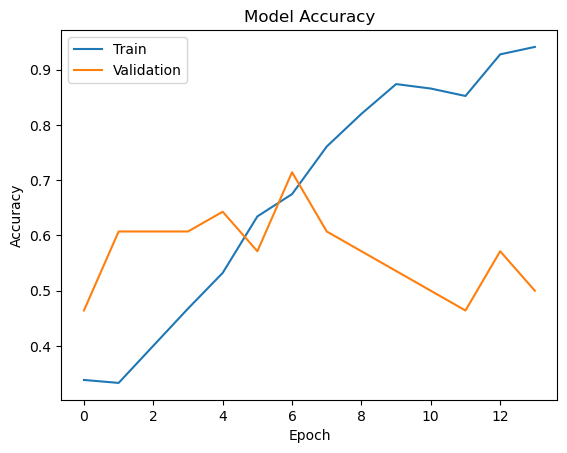

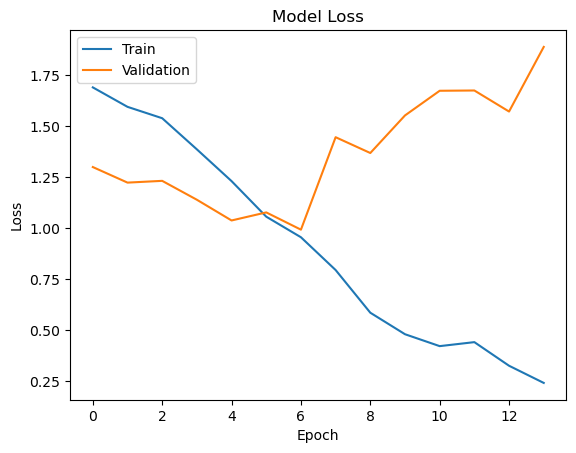

In [29]:
try:
    import matplotlib.pyplot as plt
except Exception as e:
    print("matplotlib not available — to enable plotting run: '\n'  pip install matplotlib\n  or conda install -c conda-forge matplotlib")
    print("Skipping plots.")
else:
    if 'history' in globals() and hasattr(history, 'history'):
        keys = history.history.keys()
        # Plot accuracy if available
        if 'accuracy' in keys or 'val_accuracy' in keys:
            plt.plot(history.history.get('accuracy', []))
            plt.plot(history.history.get('val_accuracy', []))
            plt.title('Model Accuracy')
            plt.ylabel('Accuracy')
            plt.xlabel('Epoch')
            plt.legend(['Train', 'Validation'], loc='upper left')
            plt.show()
        else:
            print("No accuracy keys found in history; skipping accuracy plot.")

        # Plot loss if available
        if 'loss' in keys or 'val_loss' in keys:
            plt.plot(history.history.get('loss', []))
            plt.plot(history.history.get('val_loss', []))
            plt.title('Model Loss')
            plt.ylabel('Loss')
            plt.xlabel('Epoch')
            plt.legend(['Train', 'Validation'], loc='upper left')
            plt.show()
        else:
            print("No loss keys found in history; skipping loss plot.")
    else:
        print("No 'history' object found in the notebook. Run training to generate history and then re-run this cell to plot results.")

In [30]:
# Evaluate sequence model using clip-folder validation generator

# Make sure val_gen exists
val_gen = video_generator(
    val_video_dirs, val_labels,
    batch_size=BATCH_SIZE,
    frames=16,
    num_classes=num_classes,
    shuffle=False,
    random_clip=False
)

validation_steps = max(1, len(val_video_dirs)//BATCH_SIZE)

loss, acc = seq_model.evaluate(val_gen, steps=validation_steps, verbose=1)
print("Val loss:", loss)
print("Val accuracy:", acc)


1/1 [==============================] - 3s 3s/step - loss: 1.0053 - accuracy: 0.7000
Val loss: 1.005258560180664
Val accuracy: 0.699999988079071


In [31]:

import numpy as np
import os
import cv2

class_names = ['bloody', 'explosions', 'fight', 'gun shot', 'non-violence', 'violence']
SEQ_LEN = 8

def load_clip_sequence(clip_dir, frames=SEQ_LEN):
    frame_files = sorted([
        f for f in os.listdir(clip_dir)
        if f.lower().endswith((".jpg",".jpeg",".png"))
    ])

    if len(frame_files) < frames:
        raise ValueError(f"Not enough frames in {clip_dir}. Found {len(frame_files)}")

    selected = frame_files[:frames]
    frames_data = []

    for f in selected:
        img_path = os.path.join(clip_dir, f)
        img = cv2.imread(img_path)

        if img is None:
            raise ValueError(f"Failed to read {img_path}")

        img = cv2.resize(img, (224, 224))
        img = img.astype("float32") / 255.0
        frames_data.append(img)

    x = np.expand_dims(np.array(frames_data, dtype="float32"), axis=0)
    return x

# CHANGE THIS PATH
clip_dir = r"C:\Users\Shubham\Downloads\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train\fight\clip_0026"

x = load_clip_sequence(clip_dir)

pred = seq_model.predict(x, verbose=0)

# Safe handling
if pred.ndim == 3:
    pred = np.mean(pred, axis=1)

pred_class = int(np.argmax(pred, axis=1)[0])

print("Probabilities:", pred)
print("Predicted:", class_names[pred_class])

Probabilities: [[0.18491456 0.03045408 0.5360088  0.03521113 0.20752373 0.00588777]]
Predicted: fight


In [32]:
class_names = ['bloody', 'explosions', 'fight', 'gun shot', 'non-violence', 'violence']

if pred.ndim == 3:
    pred = np.mean(pred, axis=1)

predicted_class = int(np.argmax(pred))

print("Probabilities:", pred)
print("Predicted class:", class_names[predicted_class])

Probabilities: [[0.18491456 0.03045408 0.5360088  0.03521113 0.20752373 0.00588777]]
Predicted class: fight
